In [ ]:
#載入 Google 雲端硬碟
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# RNN分類IMDB

#### 載入套件

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SpatialDropout1D
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.callbacks import ModelCheckpoint
import os
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
%matplotlib inline

#### 設定超參數

In [ ]:
# 輸出目錄名稱
output_dir = '/content/drive/MyDrive/_教材/人工智慧/自然語言程式/IMDB詞性分析範例/model_output/rnn'  #註：請記得依你存放的位置彈性修改路徑

# 訓練
epochs = 10 # 增加訓練週期
batch_size = 128

# 詞向量空間
n_dim = 64
n_unique_words = 5000
max_review_length = 100 # lowered due to vanishing gradient over time
pad_type = trunc_type = 'pre'
drop_embed = 0.2

# RNN 的循環層參數
n_rnn = 256
drop_rnn = 0.2

# 密集層參數
# n_dense = 256
# dropout = 0.2

#### 下載資料集

In [ ]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=n_unique_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### 資料預處理

In [ ]:
x_train = pad_sequences(x_train, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)
x_test = pad_sequences(x_test, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)

#### RNN 分類模型架構

In [ ]:
model = Sequential()
model.add(Embedding(n_unique_words, n_dim, input_length=max_review_length))
model.add(SpatialDropout1D(drop_embed))
model.add(SimpleRNN(n_rnn, dropout=drop_rnn))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### 編譯、訓練模型

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
modelcheckpoint = ModelCheckpoint(filepath=output_dir+"/weights.{epoch:02d}.keras")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [ ]:
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test), callbacks=[modelcheckpoint])

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.5064 - loss: 0.7030 - val_accuracy: 0.4995 - val_loss: 0.6948
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5058 - loss: 0.6945 - val_accuracy: 0.5314 - val_loss: 0.6838
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5452 - loss: 0.6860 - val_accuracy: 0.5598 - val_loss: 0.6682
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6232 - loss: 0.6432 - val_accuracy: 0.5992 - val_loss: 0.6515
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6736 - loss: 0.5917 - val_accuracy: 0.6233 - val_loss: 0.6359
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7128 - loss: 0.5510 - val_accuracy: 0.6964 - val_loss: 0.5867
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7566 - loss: 0.5023 - val_accuracy: 0.6645 - val_loss: 0.6185
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7714 - loss: 0.4759 - val_acc

#### 評估結果

In [ ]:
#視以上執行結果指定較佳的權重
model.load_weights(output_dir+"/weights.09.keras")

In [ ]:
y_hat = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


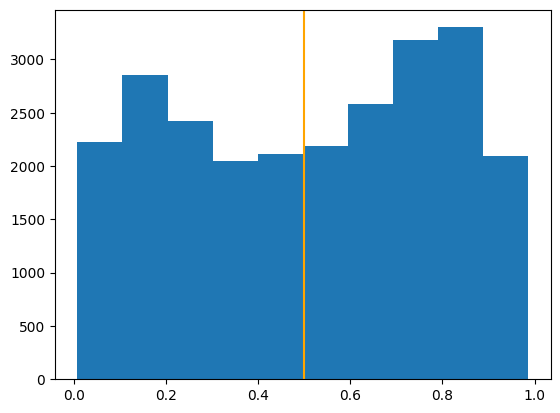

In [ ]:
plt.hist(y_hat)
_ = plt.axvline(x=0.5, color='orange')

In [ ]:
"{:0.2f}".format(roc_auc_score(y_test, y_hat)*100.0)

'90.22'